In [1]:
import numpy as np 
import pandas as pd 
import os

for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

/kaggle/input/human-bone-fractures-image-dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/README.roboflow.txt
/kaggle/input/human-bone-fractures-image-dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/data.yaml
/kaggle/input/human-bone-fractures-image-dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/labels/50_jpg.rf.947f4c229bee0c92a4e6a9ac5a57db6d.txt
/kaggle/input/human-bone-fractures-image-dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/labels/223_jpg.rf.b39b48080f6edfe1b0bd3a6b2837f7ef.txt
/kaggle/input/human-bone-fractures-image-dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/labels/246_jpg.rf.5761ae00666b864051b675665c155d87.txt
/kaggle/input/human-bone-fractures-image-dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/valid/la

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import ResNet50

2025-10-05 15:50:42.413272: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1759679442.592959      20 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1759679442.648302      20 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [3]:
base_path = "/kaggle/input/human-bone-fractures-image-dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection"

train_img_dir = os.path.join(base_path, "train/images")
valid_img_dir = os.path.join(base_path, "valid/images")
test_img_dir  = os.path.join(base_path, "test/images")

train_lbl_dir = os.path.join(base_path, "train/labels")
valid_lbl_dir = os.path.join(base_path, "valid/labels")
test_lbl_dir  = os.path.join(base_path, "test/labels")

In [4]:
def load_dataset(img_dir, lbl_dir, split):
    data = []
    for fname in os.listdir(img_dir):
        if fname.lower().endswith((".jpg", ".jpeg", ".png")):
            img_path = os.path.join(img_dir, fname)
            lbl_path = os.path.join(lbl_dir, fname.rsplit(".", 1)[0] + ".txt")
            data.append([img_path, lbl_path, split])
    return data

In [5]:
dataset = []
dataset += load_dataset(train_img_dir, train_lbl_dir, "train")
dataset += load_dataset(valid_img_dir, valid_lbl_dir, "valid")
dataset += load_dataset(test_img_dir, test_lbl_dir, "test")

In [6]:
df = pd.DataFrame(dataset, columns=["image_path", "label_path", "split"])
print("Total images:", len(df))
df.head()

Total images: 1539


,image_path,label_path,split
0,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train
1,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train
2,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train
3,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train
4,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train


In [7]:
import yaml

yaml_path = os.path.join(base_path, "data.yaml")

with open(yaml_path, "r") as f:
    data_yaml = yaml.safe_load(f)

classes = data_yaml["names"]
print("Classes:", classes)

Classes: ['Comminuted', 'Greenstick', 'Healthy', 'Linear', 'Oblique Displaced', 'Oblique', 'Segmental', 'Spiral', 'Transverse Displaced', 'Transverse']


In [8]:
def get_image_class(lbl_path):
    if not os.path.exists(lbl_path):
        return None
    with open(lbl_path, "r") as f:
        lines = f.readlines()
    if len(lines) == 0:
        return None
    # YOLO format: class_id x_center y_center width height
    first_class_id = int(lines[0].split()[0])
    return classes[first_class_id]

In [9]:
df["label"] = df["label_path"].apply(get_image_class)
df["label"].value_counts()

label
Transverse Displaced    600
Oblique Displaced       341
Comminuted              173
Transverse              107
Greenstick               83
Spiral                   74
Healthy                  64
Oblique                  57
Linear                   22
Segmental                15
Name: count, dtype: int64

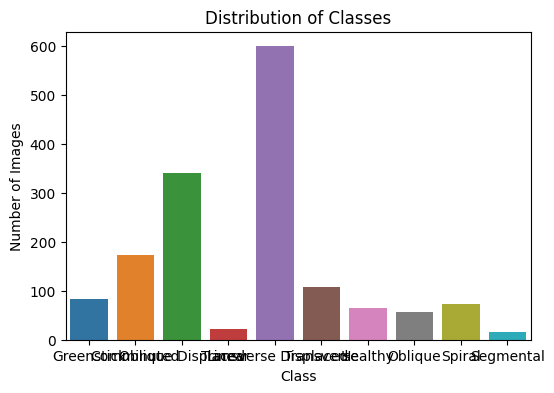

In [10]:
plt.figure(figsize=(6,4))
sns.countplot(x='label', data=df)
plt.title("Distribution of Classes")
plt.xlabel("Class")
plt.ylabel("Number of Images")
plt.show()

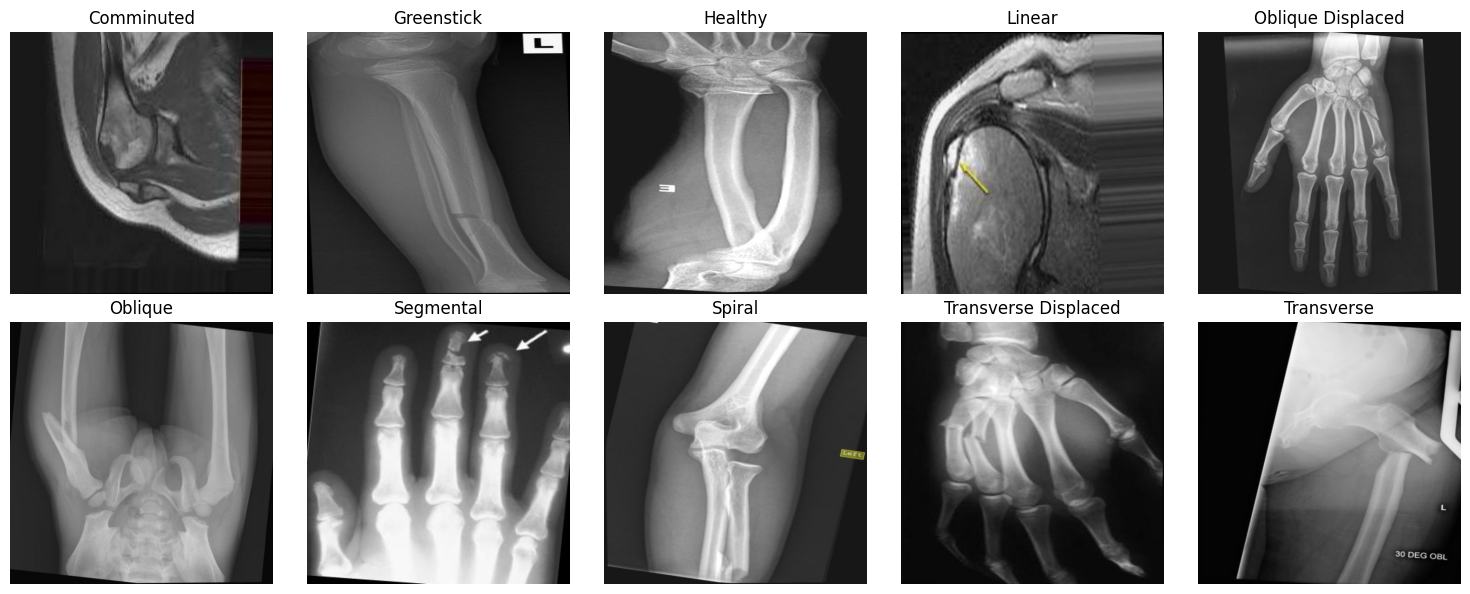

In [11]:
fig, axes = plt.subplots(2, 5, figsize=(15,6))
axes = axes.flatten()  # now axes[0], axes[1], ..., axes[9]

for i, cls in enumerate(classes[:10]):  # max 10 classes
    # take the first image of the class
    cls_images = [p for p in df[df['label']==cls]['image_path'].values if os.path.isfile(p)]
    
    if cls_images:
        try:
            img = Image.open(cls_images[0]).convert('RGB')  # first image only
            axes[i].imshow(img)
            axes[i].axis('off')
            axes[i].set_title(cls)
        except Exception as e:
            print(f"Cannot open {cls_images[0]}: {e}")
            axes[i].axis('off')
            axes[i].set_title("Error")
    else:
        axes[i].axis('off')
        axes[i].set_title("No Image")

plt.tight_layout()
plt.show()

In [12]:
widths, heights = [], []

for img_path in df['image_path']:
    if os.path.isfile(img_path):  
        try:
            img = Image.open(img_path)
            widths.append(img.width)
            heights.append(img.height)
        except Exception as e:
            print(f"Error opening {img_path}: {e}")
            widths.append(None)
            heights.append(None)
    else:
        print(f"Skipping directory: {img_path}")
        widths.append(None)
        heights.append(None)

df['width'] = widths
df['height'] = heights
df[['width','height']].describe()

,width,height
count,1539.0,1539.0
mean,640.0,640.0
std,0.0,0.0
min,640.0,640.0
25%,640.0,640.0
50%,640.0,640.0
75%,640.0,640.0
max,640.0,640.0


/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/usr/local/lib/python3.11/dist-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


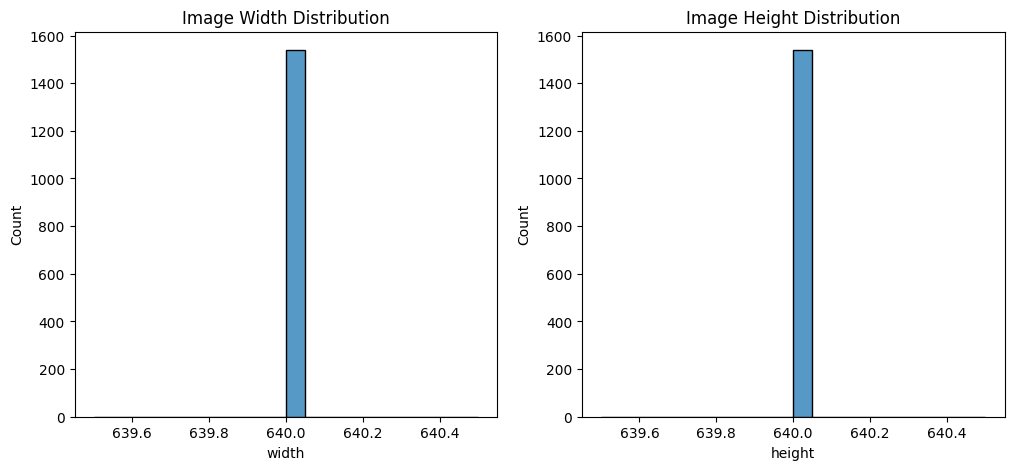

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

df_numeric = df.dropna(subset=['width', 'height'])

plt.figure(figsize=(12,5))

plt.subplot(1,2,1)
sns.histplot(df_numeric['width'], bins=20)
plt.title("Image Width Distribution")

plt.subplot(1,2,2)
sns.histplot(df_numeric['height'], bins=20)
plt.title("Image Height Distribution")

plt.show()

In [14]:
df_numeric

,image_path,label_path,split,label,width,height
0,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Greenstick,640,640
1,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Comminuted,640,640
2,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Oblique Displaced,640,640
3,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Oblique Displaced,640,640
4,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Linear,640,640
...,...,...,...,...,...,...
1534,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,test,Oblique Displaced,640,640
1535,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,test,Transverse Displaced,640,640
1536,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,test,Transverse Displaced,640,640
1537,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,test,Transverse Displaced,640,640


In [15]:
df

,image_path,label_path,split,label,width,height
0,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Greenstick,640,640
1,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Comminuted,640,640
2,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Oblique Displaced,640,640
3,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Oblique Displaced,640,640
4,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,train,Linear,640,640
...,...,...,...,...,...,...
1534,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,test,Oblique Displaced,640,640
1535,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,test,Transverse Displaced,640,640
1536,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,test,Transverse Displaced,640,640
1537,/kaggle/input/human-bone-fractures-image-datas...,/kaggle/input/human-bone-fractures-image-datas...,test,Transverse Displaced,640,640


In [16]:
corrupted = []
for img_path in df['image_path']:
    try:
        img = Image.open(img_path)
        img.verify()
    except:
        corrupted.append(img_path)

print(f"Number of corrupted images: {len(corrupted)}")

Number of corrupted images: 0


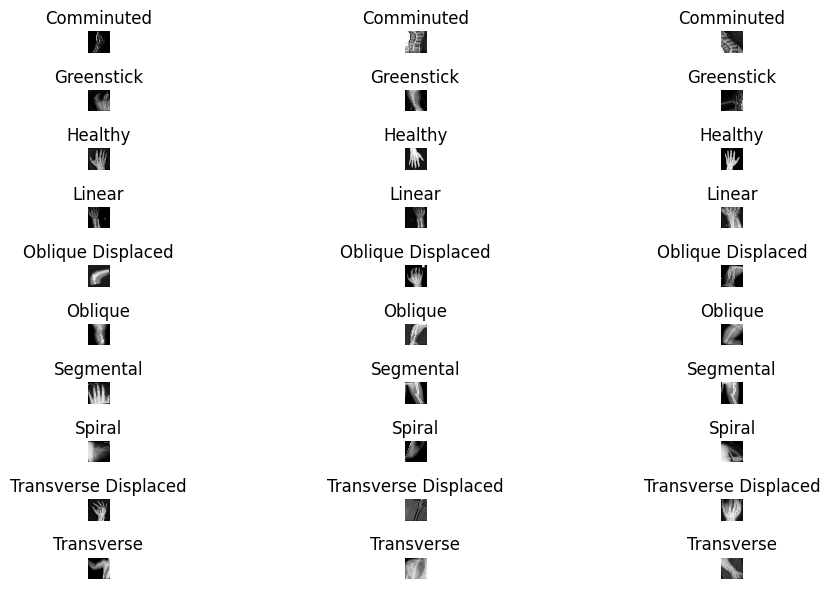

In [17]:
fig, axes = plt.subplots(len(classes), 3, figsize=(12,6))
for i, cls in enumerate(classes):
    sample_imgs = df[df['label']==cls].sample(3)['image_path'].values
    for j, img_path in enumerate(sample_imgs):
        img = Image.open(img_path)
        axes[i,j].imshow(img, cmap='gray')
        axes[i,j].axis('off')
        axes[i,j].set_title(cls)
plt.tight_layout()
plt.show()

In [18]:
def create_dataframe(split):
    image_dir = f'{base_path}/{split}/images'
    label_dir = f'{base_path}/{split}/labels'
    
    data = []
    for image_filename in os.listdir(image_dir):
        if image_filename.endswith('.jpg'):
            label_filename = os.path.splitext(image_filename)[0] + '.txt'
            label_path = os.path.join(label_dir, label_filename)
            
            try:
                with open(label_path, 'r') as f:
                    line = f.readline()
                    class_id = line.split()[0] 
                    data.append({'filename': image_filename, 'class': str(class_id)})
            except FileNotFoundError:
                print(f"Warning: Label not found for image {image_filename}")
            except IndexError:
                print(f"Warning: Label file {label_filename} is empty or malformed.")
                
    return pd.DataFrame(data)

In [19]:
train_df = create_dataframe('train')
val_df = create_dataframe('valid')

print("Train DataFrame head:\n", train_df.head())
print("\nValidation DataFrame head:\n", val_df.head())

Train DataFrame head:
                                             filename class
0      6_jpg.rf.2f66adec11758de70ce9c84e7c4596d0.jpg     1
1  29_mri_0_4706_jpeg.rf.891c2c4358f315f5b89eb75f...     0
2    180_jpg.rf.e7e68f6f713b060a0f489cd1a1d200a5.jpg     4
3     35_jpg.rf.f209c58c375b612b16e20f93276c297c.jpg     4
4  26_mri_0_7467_jpeg.rf.a14983102a995095c89ff14d...     3

Validation DataFrame head:
                                           filename class
0   41_jpg.rf.b489fc8e3d5b30c5f52489a8261fb1eb.jpg     8
1   21_jpg.rf.d146a4a16cc8b656ff6a2cbb4a8e73e9.jpg     9
2   10_jpg.rf.a4b19c387d1e604e7dff1f95d7361bde.jpg     8
3   24_jpg.rf.aae5ab3f2f0aef803d5c9510f8c2165d.jpg     5
4  232_jpg.rf.498d4947d9d5e372b2f41a8aec432e60.jpg     8


In [20]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)

val_datagen = ImageDataGenerator(rescale=1./255)

In [21]:
train_gen = train_datagen.flow_from_dataframe(
    dataframe=train_df,
    directory=f'{base_path}/train/images', 
    x_col='filename',     
    y_col='class',         
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical' 
)

Found 1344 validated image filenames belonging to 10 classes.


In [22]:
val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=f'{base_path}/valid/images/',
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

Found 128 validated image filenames belonging to 10 classes.


Insights derived :
The Human Bone Fractures Image Dataset from Kaggle contains 1,539 X-ray images categorized into 10 classes of different fracture types and healthy bones, all resized to 640x640 pixels for consistency. The dataset is highly imbalanced, with Transverse Displaced fractures being the most common (600 images) and Segmental fractures being the least represented (15 images). Other classes include Oblique Displaced (341), Comminuted (173), Transverse (107), Greenstick (83), Spiral (74), Healthy (64), Oblique (57), and Linear (22). The images show noticeable variation in bone position, angle, and brightness, suggesting that preprocessing steps like normalization and contrast enhancement will be useful. Some fracture types, such as Oblique and Oblique Displaced, appear visually similar, which may cause confusion during classification. Because of the uneven distribution, using techniques such as class weights, data augmentation, and stratified data splits will help improve model balance and performance. Overall, the dataset provides a diverse collection of fracture images suitable for training deep learning models, but careful handling of imbalance and image variation is necessary to achieve accurate and reliable results.


Using EfficientNetV2

In [23]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image

import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Dense, Dropout, GlobalAveragePooling2D
from tensorflow.keras.applications import EfficientNetV2B0
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping
from sklearn.metrics import classification_report, confusion_matrix


In [24]:
IMG_SIZE = (224, 224)
IMG_SHAPE = IMG_SIZE + (3,)
NUM_CLASSES = 10  
BATCH_SIZE = 32   
EPOCHS = 30


In [25]:
base_model = EfficientNetV2B0(
    input_shape=IMG_SHAPE,
    include_top=False,   # exclude final classification layer
    weights='imagenet'
)

base_model.trainable = False  # freeze base model for transfer learning

print(f"Base model has {len(base_model.layers)} layers.")


I0000 00:00:1759679476.058928      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:0 with 13942 MB memory:  -> device: 0, name: Tesla T4, pci bus id: 0000:00:04.0, compute capability: 7.5
I0000 00:00:1759679476.059889      20 gpu_device.cc:2022] Created device /job:localhost/replica:0/task:0/device:GPU:1 with 13942 MB memory:  -> device: 1, name: Tesla T4, pci bus id: 0000:00:05.0, compute capability: 7.5


24274472/24274472 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Base model has 270 layers.


In [26]:
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.4)(x)  
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

model = Model(inputs, outputs)

optimizer = tf.keras.optimizers.Adam(learning_rate=0.0008)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

model.summary()


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ efficientnetv2-b0 (Functional)  │ (None, 7, 7, 1280)     │     5,919,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,932,122 (22.63 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 5,919,312 (22.58 MB)

In [27]:
checkpoint = ModelCheckpoint(
    "best_efficientnetv2_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5,
    restore_best_weights=True
)
num_classes = len(train_gen.class_indices)


In [28]:
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stopping]
)
output = Dense(num_classes, activation='softmax')(x)



/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


Epoch 1/30


I0000 00:00:1759679498.989622      66 service.cc:148] XLA service 0x787ec8013b80 initialized for platform CUDA (this does not guarantee that XLA will be used). Devices:
I0000 00:00:1759679498.990408      66 service.cc:156]   StreamExecutor device (0): Tesla T4, Compute Capability 7.5
I0000 00:00:1759679498.990434      66 service.cc:156]   StreamExecutor device (1): Tesla T4, Compute Capability 7.5
I0000 00:00:1759679501.093355      66 cuda_dnn.cc:529] Loaded cuDNN version 90300


 2/42 ━━━━━━━━━━━━━━━━━━━━ 2s 55ms/step - accuracy: 0.1172 - loss: 2.2928  

I0000 00:00:1759679512.803641      66 device_compiler.h:188] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.


42/42 ━━━━━━━━━━━━━━━━━━━━ 57s 610ms/step - accuracy: 0.2995 - loss: 1.9701 - val_accuracy: 0.3672 - val_loss: 1.8850
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 418ms/step - accuracy: 0.3926 - loss: 1.8347 - val_accuracy: 0.3672 - val_loss: 1.8934
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 418ms/step - accuracy: 0.3794 - loss: 1.8659 - val_accuracy: 0.3672 - val_loss: 1.8897
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 424ms/step - accuracy: 0.3628 - loss: 1.8397 - val_accuracy: 0.3672 - val_loss: 1.9003
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 426ms/step - accuracy: 0.4161 - loss: 1.7928 - val_accuracy: 0.3672 - val_loss: 1.8761
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 423ms/step - accuracy: 0.3516 - loss: 1.8355 - val_accuracy: 0.3672 - val_loss: 1.8968


In [29]:
model.load_weights("best_efficientnetv2_model.keras")
loss, accuracy = model.evaluate(val_gen)
print(f"\nFinal Validation Accuracy: {accuracy*100:.2f}%")
print(f"Final Validation Loss: {loss:.4f}")


4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 135ms/step - accuracy: 0.3854 - loss: 1.9220

Final Validation Accuracy: 36.72%
Final Validation Loss: 1.8850


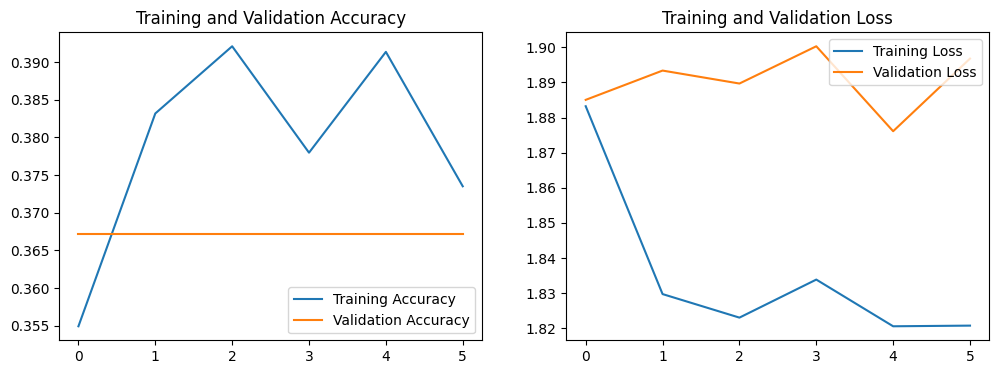

In [30]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()


In [31]:
val_datagen = ImageDataGenerator(rescale=1./255)
val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=f'{base_path}/valid/images/',
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False
)

class_indices = val_gen.class_indices
class_map = {v: k for k, v in class_indices.items()}

print("\nClass Mapping:")
print(class_map)


Found 128 validated image filenames belonging to 10 classes.

Class Mapping:
{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


In [32]:
from tensorflow.keras.preprocessing.image import load_img, img_to_array

def predict_single_image(image_path, model, class_map):
    try:
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array /= 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        
        prediction = model.predict(img_batch)
        predicted_index = np.argmax(prediction[0])
        predicted_class_name = class_map[predicted_index]
        confidence = np.max(prediction[0]) * 100
        
        return predicted_class_name, confidence
        
    except FileNotFoundError:
        return f"Error: Image not found at {image_path}", None


1/1 ━━━━━━━━━━━━━━━━━━━━ 8s 8s/step

--- Single Image Inference ---
Image Path: /kaggle/input/human-bone-fractures-image-dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/101_jpg.rf.92e32f9dfb9b34f9a123b16629cc368d.jpg
Predicted Class: 8
Confidence: 39.80%


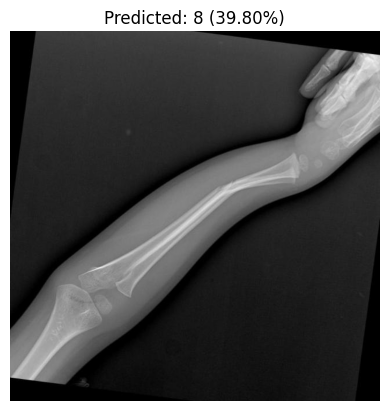

In [33]:
test_image_path = f'{base_path}/test/images/101_jpg.rf.92e32f9dfb9b34f9a123b16629cc368d.jpg'
predicted_class, confidence = predict_single_image(test_image_path, model, class_map)

if confidence is not None:
    print(f"\n--- Single Image Inference ---")
    print(f"Image Path: {test_image_path}")
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")

    plt.imshow(load_img(test_image_path))
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()


In [34]:
class_indices_full = val_gen.class_indices 
class_labels_full = list(class_indices_full.keys())
class_indices_list_full = list(range(len(class_labels_full)))

predictions = model.predict(val_gen)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_gen.classes

print("\n--- Classification Report ---")
report = classification_report(
    true_classes,
    predicted_classes,
    labels=class_indices_list_full,
    target_names=class_labels_full,
    zero_division=0
)
print(report)


/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 8s 105ms/step

--- Classification Report ---
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        14
           1       0.00      0.00      0.00         7
           2       0.00      0.00      0.00         7
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00        28
           5       0.00      0.00      0.00         7
           6       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         5
           8       0.37      1.00      0.54        47
           9       0.00      0.00      0.00         9

    accuracy                           0.37       128
   macro avg       0.04      0.10      0.05       128
weighted avg       0.13      0.37      0.20       128




--- Confusion Matrix ---


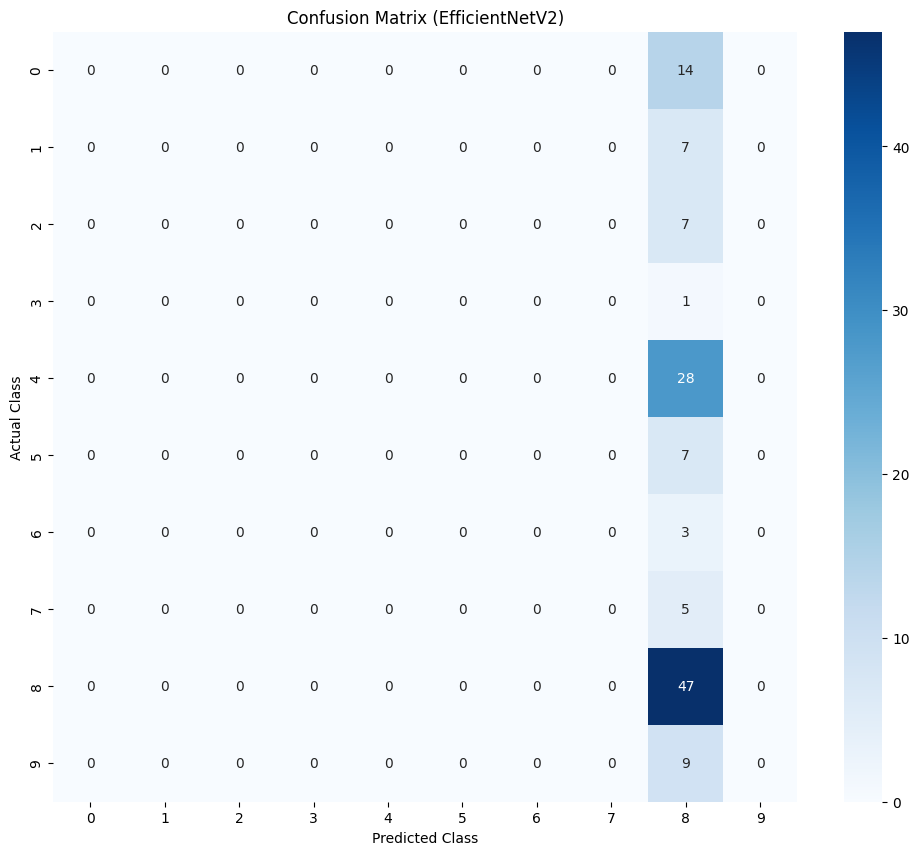

In [35]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(true_classes, predicted_classes, labels=class_indices_list_full)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_full,
            yticklabels=class_labels_full)
plt.title('Confusion Matrix (EfficientNetV2)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()


## Using MobileNetV2

In [36]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.callbacks import ModelCheckpoint, EarlyStopping

In [37]:
IMG_SIZE = (224, 224)
IMG_SHAPE = IMG_SIZE + (3,)
NUM_CLASSES = 10  
BATCH_SIZE = 32   
EPOCHS = 30 

In [38]:
base_model = MobileNetV2(
    input_shape=IMG_SHAPE,
    include_top=False, 
    weights='imagenet'
)

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step


In [39]:
base_model.trainable = False
print(f"Base model has {len(base_model.layers)} layers.")

Base model has 154 layers.


In [40]:
inputs = tf.keras.Input(shape=IMG_SHAPE)
x = base_model(inputs, training=False)
x = GlobalAveragePooling2D()(x)
x = Dropout(0.3)(x)
outputs = Dense(NUM_CLASSES, activation='softmax')(x)

In [41]:
model = Model(inputs, outputs)
optimizer = tf.keras.optimizers.Adam(learning_rate=0.001)

model.compile(
    optimizer=optimizer,
    loss='categorical_crossentropy', 
    metrics=['accuracy']
)

model.summary()

Model: "functional_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_3 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_1      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 10)             │        12,810 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,270,794 (8.66 MB)

 Trainable params: 12,810 (50.04 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [42]:
checkpoint = ModelCheckpoint(
    "best_model.keras",
    monitor='val_accuracy',
    save_best_only=True,
    mode='max'
)

In [43]:
early_stopping = EarlyStopping(
    monitor='val_accuracy',
    patience=5, # Stop after 5 epochs of no improvement
    restore_best_weights=True
)

In [44]:
history = model.fit(
    train_gen,
    epochs=EPOCHS,
    validation_data=val_gen,
    callbacks=[checkpoint, early_stopping]
)

Epoch 1/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 32s 509ms/step - accuracy: 0.2895 - loss: 2.1504 - val_accuracy: 0.5000 - val_loss: 1.4804
Epoch 2/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 430ms/step - accuracy: 0.4365 - loss: 1.5383 - val_accuracy: 0.5625 - val_loss: 1.3532
Epoch 3/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 19s 445ms/step - accuracy: 0.5128 - loss: 1.3266 - val_accuracy: 0.5859 - val_loss: 1.2591
Epoch 4/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 424ms/step - accuracy: 0.5598 - loss: 1.1832 - val_accuracy: 0.5859 - val_loss: 1.1861
Epoch 5/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 420ms/step - accuracy: 0.5673 - loss: 1.1704 - val_accuracy: 0.6250 - val_loss: 1.1342
Epoch 6/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 413ms/step - accuracy: 0.6246 - loss: 1.0358 - val_accuracy: 0.6172 - val_loss: 1.0526
Epoch 7/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 18s 420ms/step - accuracy: 0.6572 - loss: 0.9562 - val_accuracy: 0.6953 - val_loss: 1.0056
Epoch 8/30
42/42 ━━━━━━━━━━━━━━━━━━━━ 17s 405ms/step - accuracy: 0.6898 - loss: 0.8876 - val_accu

In [45]:
model.load_weights("best_model.keras")

In [46]:
loss, accuracy = model.evaluate(val_gen)
print(f"\nFinal Validation Accuracy: {accuracy*100:.2f}%")
print(f"Final Validation Loss: {loss:.4f}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 111ms/step - accuracy: 0.8104 - loss: 0.7033

Final Validation Accuracy: 82.03%
Final Validation Loss: 0.6920


In [47]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

Text(0.5, 1.0, 'Training and Validation Accuracy')

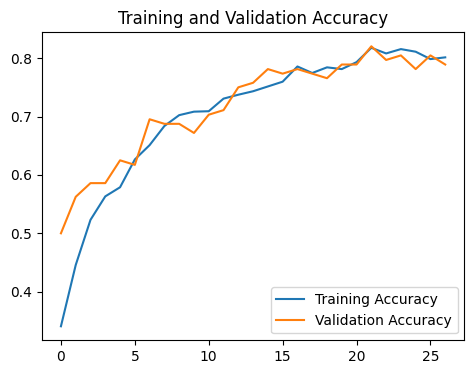

In [48]:
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

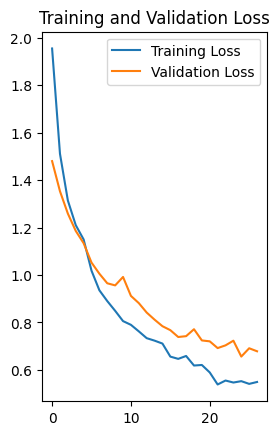

In [49]:
plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

### Inference and Analysis

In [50]:
from sklearn.metrics import classification_report, confusion_matrix
from tensorflow.keras.preprocessing.image import ImageDataGenerator, load_img, img_to_array

In [51]:
val_datagen = ImageDataGenerator(rescale=1./255)
val_gen = val_datagen.flow_from_dataframe(
    dataframe=val_df,
    directory=f'{base_path}/valid/images/',
    x_col='filename',
    y_col='class',
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical',
    shuffle=False 
)

class_indices = val_gen.class_indices
class_map = {v: k for k, v in class_indices.items()}

print("\nClass Mapping:")
print(class_map)

Found 128 validated image filenames belonging to 10 classes.

Class Mapping:
{0: '0', 1: '1', 2: '2', 3: '3', 4: '4', 5: '5', 6: '6', 7: '7', 8: '8', 9: '9'}


In [52]:
def predict_single_image(image_path, model, class_map):
    """
    Loads an image, preprocesses it, and returns the predicted class and confidence.
    """
    try:
        img = load_img(image_path, target_size=(224, 224))
        img_array = img_to_array(img)
        img_array /= 255.0
        img_batch = np.expand_dims(img_array, axis=0)
        
        prediction = model.predict(img_batch)
        
        predicted_index = np.argmax(prediction[0])
        predicted_class_name = class_map[predicted_index]
        confidence = np.max(prediction[0]) * 100
        
        return predicted_class_name, confidence
        
    except FileNotFoundError:
        return f"Error: Image not found at {image_path}", None

In [53]:
test_image_path = f'{base_path}/test/images/101_jpg.rf.92e32f9dfb9b34f9a123b16629cc368d.jpg' 

1/1 ━━━━━━━━━━━━━━━━━━━━ 4s 4s/step

--- Single Image Inference ---
Image Path: /kaggle/input/human-bone-fractures-image-dataset/Human Bone Fractures Multi-modal Image Dataset (HBFMID)/Bone Fractures Detection/test/images/101_jpg.rf.92e32f9dfb9b34f9a123b16629cc368d.jpg
Predicted Class: 7
Confidence: 87.62%


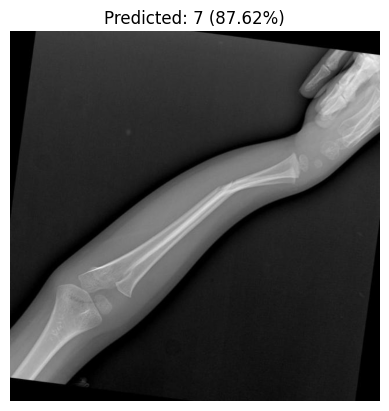

In [54]:
predicted_class, confidence = predict_single_image(test_image_path, model, class_map)

if confidence is not None:
    print(f"\n--- Single Image Inference ---")
    print(f"Image Path: {test_image_path}")
    print(f"Predicted Class: {predicted_class}")
    print(f"Confidence: {confidence:.2f}%")
    
    plt.imshow(load_img(test_image_path))
    plt.title(f"Predicted: {predicted_class} ({confidence:.2f}%)")
    plt.axis('off')
    plt.show()

In [55]:
class_indices_full = val_gen.class_indices 
class_labels_full = list(class_indices_full.keys())
class_indices_list_full = list(range(len(class_labels_full))) 

print("Full list of 10 class labels:", class_labels_full)
print("Full list of 10 class indices:", class_indices_list_full)

Full list of 10 class labels: ['0', '1', '2', '3', '4', '5', '6', '7', '8', '9']
Full list of 10 class indices: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9]


In [56]:
predictions = model.predict(val_gen)
predicted_classes = np.argmax(predictions, axis=1)
true_classes = val_gen.classes

/usr/local/lib/python3.11/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


4/4 ━━━━━━━━━━━━━━━━━━━━ 5s 91ms/step


In [57]:
print("\n--- Classification Report ---")
report = classification_report(
    true_classes,
    predicted_classes,
    labels=class_indices_list_full,   
    target_names=class_labels_full,
    zero_division=0                
)
print(report)


--- Classification Report ---
              precision    recall  f1-score   support

           0       0.85      0.79      0.81        14
           1       0.75      0.86      0.80         7
           2       0.67      0.86      0.75         7
           3       1.00      1.00      1.00         1
           4       0.91      0.75      0.82        28
           5       1.00      0.71      0.83         7
           6       1.00      1.00      1.00         3
           7       1.00      1.00      1.00         5
           8       0.76      0.83      0.80        47
           9       0.80      0.89      0.84         9

    accuracy                           0.82       128
   macro avg       0.87      0.87      0.87       128
weighted avg       0.83      0.82      0.82       128




--- Confusion Matrix ---


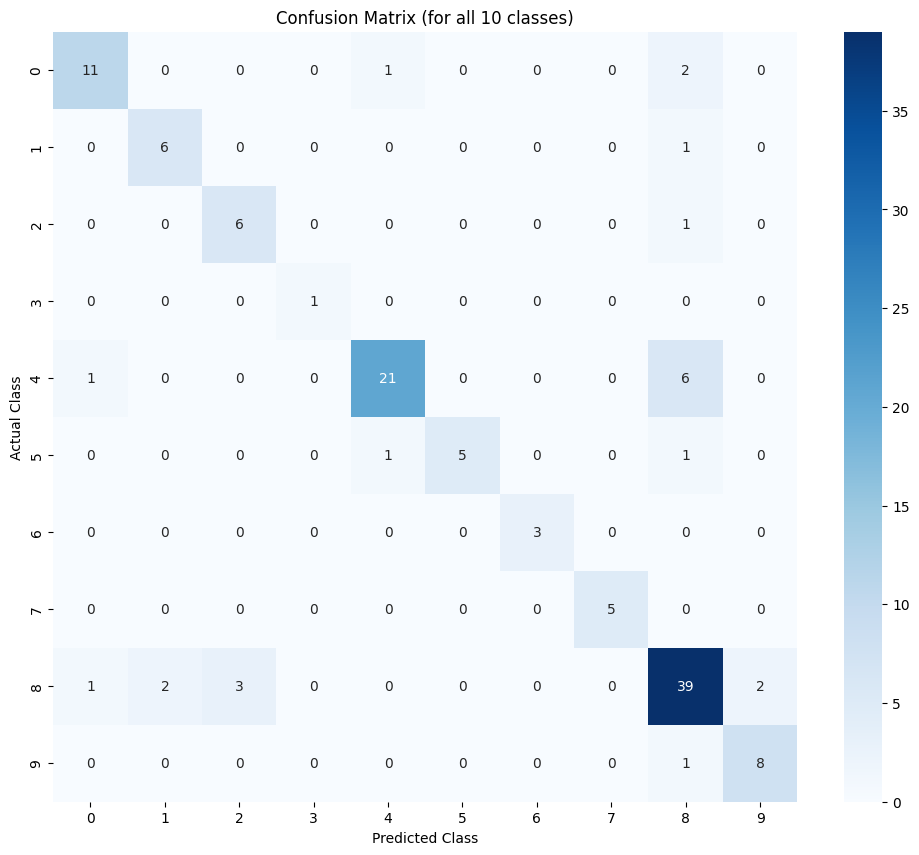

In [58]:
print("\n--- Confusion Matrix ---")
cm = confusion_matrix(true_classes, predicted_classes, labels=class_indices_list_full)

plt.figure(figsize=(12, 10))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=class_labels_full,
            yticklabels=class_labels_full)
plt.title('Confusion Matrix (for all 10 classes)')
plt.ylabel('Actual Class')
plt.xlabel('Predicted Class')
plt.show()

In [59]:
images, labels = next(val_gen)
true_labels = np.argmax(labels, axis=1)

batch_predictions = model.predict(images)
predicted_labels = np.argmax(batch_predictions, axis=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step


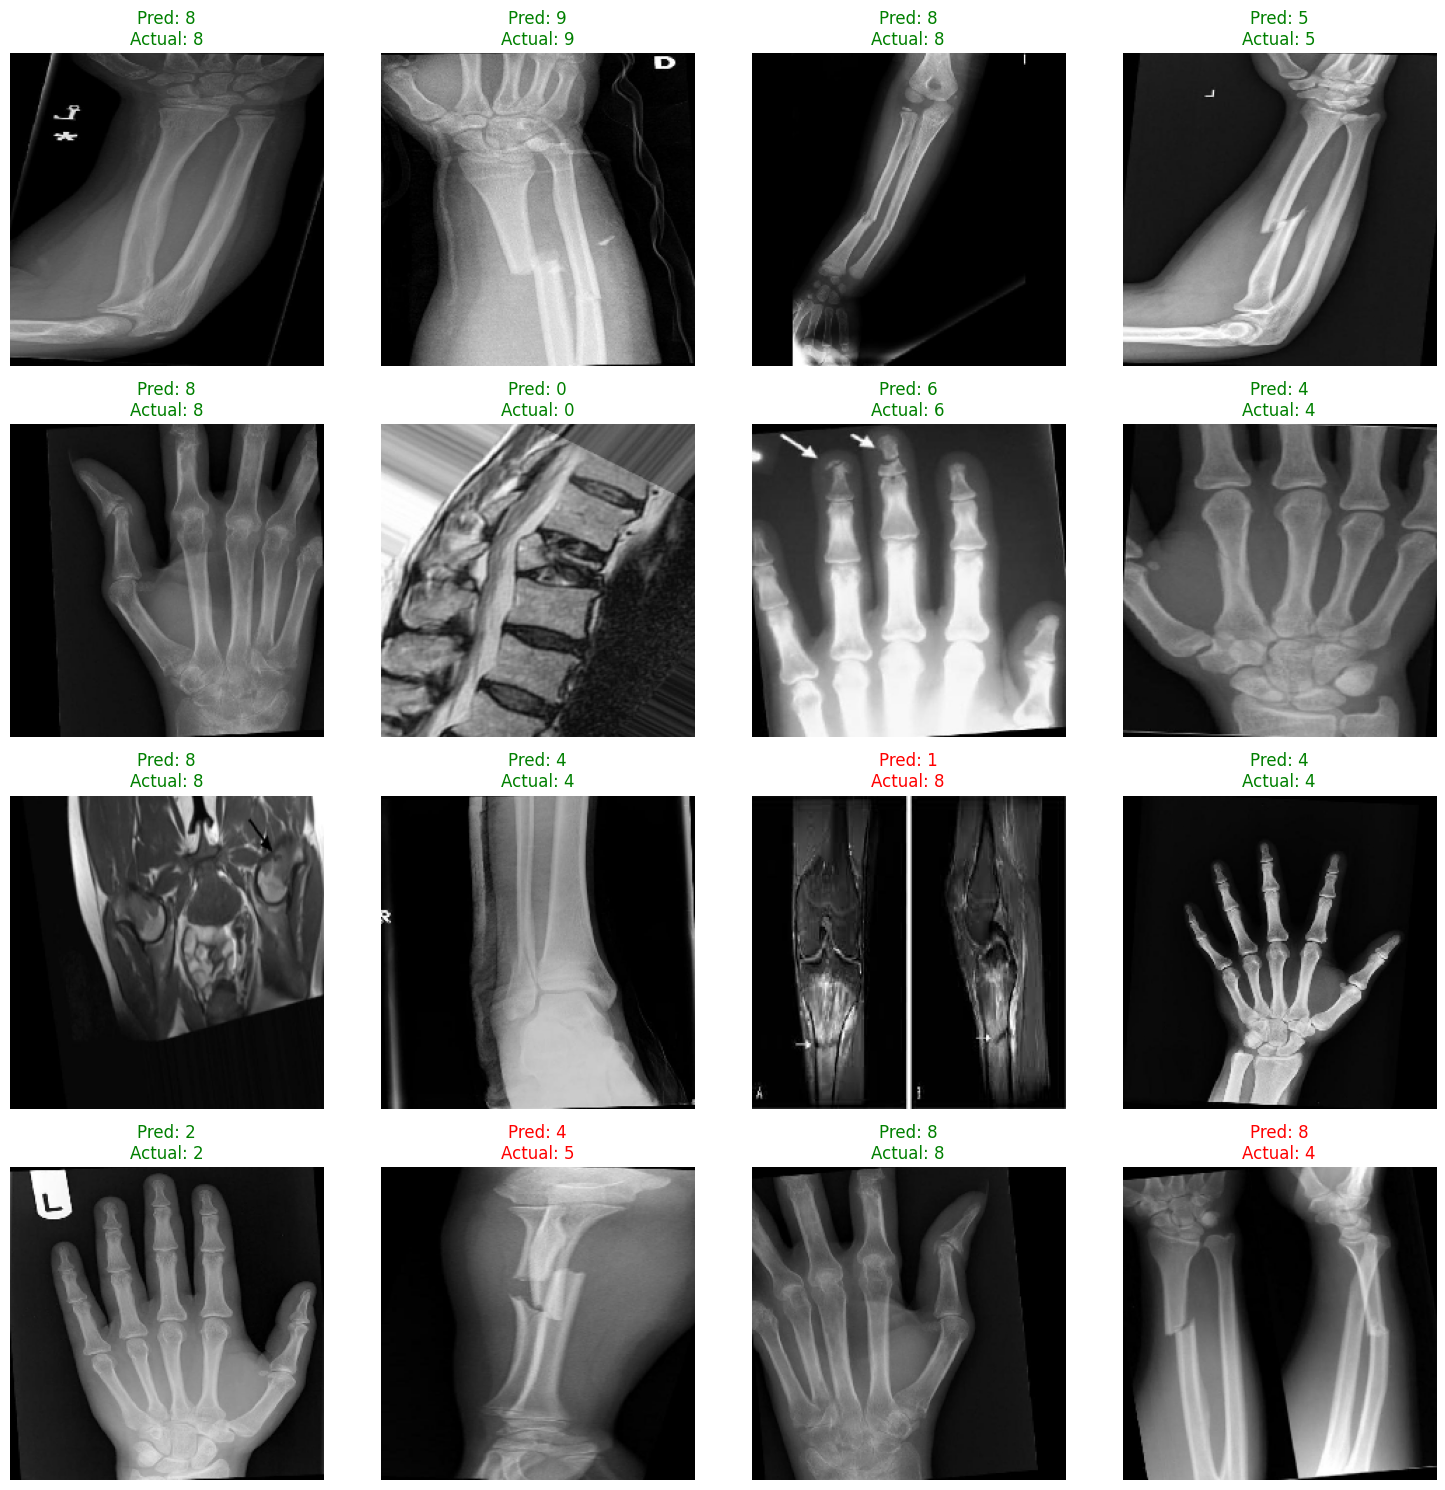

In [60]:
plt.figure(figsize=(15, 15))
for i in range(min(len(images), 16)):
    plt.subplot(4, 4, i + 1)
    plt.imshow(images[i])
    
    pred_class_name = class_map[predicted_labels[i]]
    true_class_name = class_map[true_labels[i]]
    
    title_color = 'green' if pred_class_name == true_class_name else 'red'
    
    plt.title(f"Pred: {pred_class_name}\nActual: {true_class_name}", color=title_color)
    plt.axis('off')

plt.tight_layout()
plt.show()

## ResNet (not optimal)

In [61]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224,224,3))
base_model.trainable = False

94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step


In [62]:
x = base_model.output
x = GlobalAveragePooling2D()(x)
x = Dense(128, activation='relu')(x)
x = Dropout(0.5)(x)
output = Dense(1, activation='sigmoid')(x)

In [63]:
model = Model(inputs=base_model.input, outputs=output)
model.compile(optimizer='adam', loss='binary_crossentropy', metrics=['accuracy'])
# model.summary()

In [64]:
history = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10
)

Epoch 1/10


ValueError: Arguments `target` and `output` must have the same shape. Received: target.shape=(None, 10), output.shape=(None, 1)

In [ ]:
plt.plot(history.history['accuracy'], label='train_acc')
plt.plot(history.history['val_accuracy'], label='val_acc')
plt.title("Training vs Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.show()

In [ ]:
from tensorflow.keras.preprocessing import image

img_path = df['image_path'].sample(1).values[0]  # random sample
img = image.load_img(img_path, target_size=(224,224))
img_array = image.img_to_array(img)/255.0
img_array = np.expand_dims(img_array, axis=0)

prediction = model.predict(img_array)
print("Predicted:", "Fracture" if prediction[0][0]>0.5 else "No_Fracture")
print("Actual:", df[df['image_path']==img_path]['label'].values[0])